# Training

In [2]:
# Imports for Training #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, ReLU, MaxPool2D, BatchNormalization, Concatenate, Add, Flatten, Dense
from tensorflow.keras.models import Model
from qkeras.qlayers import QConv2D, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

In [3]:
# Constants #

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

MIN_OFFSET_X = -4
MAX_OFFSET_X = 4

MIN_OFFSET_Y = -4
MAX_OFFSET_Y = 4

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

scaling_arr = np.array([48.0, 48.0, 24.0, 24.0, np.pi/2], dtype=np.float32)

In [5]:
# Generate Gaussian Functions #

def img_gen(VERBOSE: bool = False) -> tuple:

    # Randomize params
    center_x = GAUSSIAN_X // 2
    center_y = GAUSSIAN_Y // 2

    center_x += np.random.randint(MIN_OFFSET_X, MAX_OFFSET_X)
    center_y += np.random.randint(MIN_OFFSET_Y, MAX_OFFSET_Y)

    std_x = np.random.randint(MIN_STD_X, MAX_STD_X)
    std_y = np.random.randint(MIN_STD_Y, MAX_STD_Y)
    theta = np.random.uniform(MIN_THETA, MAX_THETA)
    
    intensity = MIN_INTENSITY + np.random.rand() * (MAX_INTENSITY - MIN_INTENSITY)
        
    # Generate Gaussian
    params = np.array([center_x, center_y, std_x, std_y, theta])
    gaussian = np.array(gaussian_gen(*params))
    gaussian = (gaussian / gaussian.max()) * intensity * 255
    gaussian = gaussian.astype(np.uint8)

    return (gaussian, params)

X, Y = np.meshgrid(
    np.arange(GAUSSIAN_X),
    np.arange(GAUSSIAN_Y)
)
def gaussian_gen(center_x: float, center_y: float, std_x: float, std_y: float, theta: float, X=X, Y=Y) -> np.ndarray:
    
    cos_theta_sqrd = np.power(np.cos(theta),2)
    sin_theta_sqrd = np.power(np.sin(theta),2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(-(a * (X - center_x)**2 + 2*b * (X - center_x) * (Y - center_y) + c * (Y - center_y)**2))

    return np.expand_dims(gaussian, -1)

def img_visualization_one(img: np.ndarray, params: np.ndarray) -> None:
    
    img = np.squeeze(img)
    rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    if params is not None:
        print(
        f"[(c_x, c_y)]: ({params[0]:<3}, {params[1]:<3}) "
        f"[(s_x, s_y)]: ({params[2]:<3}, {params[3]:<3}) "
        f"[Theta]: {params[4]:.2f} "
        )
    
    plt.imshow(rgb_image)
    plt.axis('off')

[(c_x, c_y)]: (20.0, 22.0) [(s_x, s_y)]: (6.0, 8.0) [Theta]: 2.60 


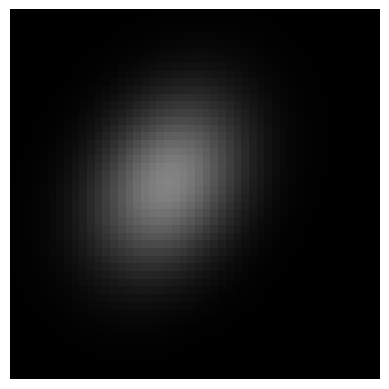

In [11]:
# Test Generate Functions #

img, params = img_gen()
img_visualization_one(img, params)

In [ ]:
# Generate Training Dataset #
SAMPLE_COUNT = 1000

img_arr = []
label_arr = []

def process_image():
    img, label = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(SAMPLE_COUNT)]
    for future in tqdm(as_completed(futures), total=SAMPLE_COUNT):
        img, label = future.result()
        img_arr.append((img.astype(np.float32)) / 256.0)            # Normalize values to [0, 1)
        label_arr.append((label.astype(np.float32)) / scaling_arr)  # Normalize w/ Scaling Array

img_arr = np.array(img_arr).astype(np.float32)
label_arr = np.array(label_arr).astype(np.float32)

print(f'[Images Shape]: {img_arr.shape}')
print(f'[Labels Shape]: {label_arr.shape}')

100%|██████████| 1000/1000 [00:00<00:00, 19665.35it/s]

[Images Shape]: (1000, 48, 48, 1)
[Labels Shape]: (1000, 5)


In [13]:
# Create Validation Dataset for Training #
VAL_COUNT = 100

img_arr_val_t = []
label_arr_val_t = []

def process_image():
    img, label = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(VAL_COUNT)]
    for future in tqdm(as_completed(futures), total=VAL_COUNT):
        img, label = future.result()
        img_arr_val_t.append((img.astype(np.float32)) / 256.0)              # Normalize values to [0, 1)
        label_arr_val_t.append((label.astype(np.float32)) / scaling_arr)    # Normalize w/ Scaling Array

img_arr_val_t = np.array(img_arr_val_t).astype(np.float32)
label_arr_val_t = np.array(label_arr_val_t).astype(np.float32)

print(f'[Images Shape]: {img_arr_val_t.shape}')
print(f'[Labels Shape]: {label_arr_val_t.shape}')

100%|██████████| 100/100 [00:00<00:00, 30092.58it/s]

[Images Shape]: (100, 48, 48, 1)
[Labels Shape]: (100, 5)


In [14]:
# Convert Data to TF Dataset #
BATCH_SIZE = 25

dataset = tf.data.Dataset.from_tensor_slices((img_arr, label_arr))
dataset = dataset.shuffle(SAMPLE_COUNT, reshuffle_each_iteration=True)
dataset = dataset.batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((img_arr_val_t, label_arr_val_t))
val_dataset = val_dataset.shuffle(VAL_COUNT, reshuffle_each_iteration=True)
val_dataset = val_dataset.batch(BATCH_SIZE)

W0000 00:00:1776993683.059885   47722 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [15]:
# Model Architecture # 

input_layer = Input(shape=(GAUSSIAN_X, GAUSSIAN_Y, 1), name='InputLayer')

x = Conv2D(filters=6, kernel_size=3, strides=1, padding='valid', kernel_initializer='lecun_uniform')(input_layer)
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=4, strides=4)(x)

x = Conv2D(filters=8, kernel_size=3, strides=1, padding='valid', kernel_initializer='lecun_uniform')(x)
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=2, strides=2)(x)

x = Conv2D(filters=10, kernel_size=3, strides=1, padding='valid', kernel_initializer='lecun_uniform')(x)
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-03)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=2, strides=2)(x)

x = Flatten()(x)
x = Dense(units=15, activation='relu')(x)
x = Dense(units=10, activation='relu')(x)

x_params = Dense(units=5, activation='linear')(x)

gaussian_tf = Model(inputs=input_layer, outputs=x_params, name='gaussian')

In [16]:
# Tensorflow Functions #

# huber loss
def dice_loss(y_true, y_pred, delta=0.5):

    weights = tf.constant([3.0, 1.0, 2.0, 2.0, 0.1], dtype=tf.float32)
    y_pred = y_pred * scaling_arr + 1e-8
    diff = y_true - y_pred
    abs_diff = tf.abs(diff)

    quadratic = tf.minimum(abs_diff, delta)
    linear = abs_diff - quadratic
    huber_loss = 0.5 * tf.square(quadratic) + delta * linear

    weighted_loss = weights * huber_loss
    return tf.reduce_mean(weighted_loss)

In [17]:
# Train or Load #
TRAIN_MODEL = True
LOAD_MODEL = False

MODEL_NAME = '[Gaus]_[Generated]_[48]_Q[10,2].keras'
NUM_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 1e-4

if (TRAIN_MODEL and LOAD_MODEL):
    print("Are you sure you want to Train & Load ?")

elif (TRAIN_MODEL):
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.01,
        decay_steps=NUM_EPOCHS,
        decay_rate=0.9)
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    gaussian_tf.compile(optimizer=adam_optimizer, loss=dice_loss, run_eagerly=True)

    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None

    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0
        
        for batch in tqdm(dataset):
            with tf.GradientTape() as tape:
                prediction = gaussian_tf(batch[0], training=True)
                loss = dice_loss(batch[1], prediction)
            grads = tape.gradient(loss, gaussian_tf.trainable_variables)
            adam_optimizer.apply_gradients(zip(grads, gaussian_tf.trainable_variables))
            running_loss += loss.numpy()
            
        average_loss = running_loss / len(dataset)

        val_running_loss = 0.0
        for val_batch in val_dataset: 
            val_prediction = gaussian_tf(val_batch[0], training=False)
            val_loss = dice_loss(batch[1], prediction)
            val_running_loss += val_loss.numpy()
        
        average_val_loss = val_running_loss / len(val_dataset)

        print(
            f"Epoch [{epoch+1}/{NUM_EPOCHS}], "
            f"Loss: {average_loss:.6f}, "
            f"Val Loss: {average_val_loss:.6f}"
        )

        if average_val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = average_val_loss
            patience_counter = 0
            best_weights = gaussian_tf.get_weights()
        else:
            patience_counter += 1
            print(f"No improvement for {patience_counter} epoch(s).")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

    if best_weights is not None:
        gaussian_tf.set_weights(best_weights)
        print(f"Restored best model weights with val loss {best_val_loss:.6f}")

    # Translate Weights Qkeras to Keras #
    # for q_layer, plain_layer in zip(gaussian_tf.layers, baby_yolo_tf.layers):
    #     if q_layer.weights and plain_layer.weights:
    #         plain_layer.set_weights(q_layer.get_weights())

elif (LOAD_MODEL):
    gaussian_tf = tf.keras.models.load_model(
        f'/home/pujan/Research/Rheed-Gaussian/Models/{MODEL_NAME}',
        custom_objects={"loss_p": loss_p}
    )

gaussian_tf.summary()

100%|██████████| 40/40 [00:00<00:00, 41.22it/s]


Epoch [1/100], Loss: 0.319979, Val Loss: 0.010079


100%|██████████| 40/40 [00:00<00:00, 45.23it/s]


Epoch [2/100], Loss: 0.007679, Val Loss: 0.006328


100%|██████████| 40/40 [00:00<00:00, 45.54it/s]


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 46, 46, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 8)        │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 9, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 10)       │           730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 10)       │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 2, 2, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,023 (19.62 KB)

 Trainable params: 1,658 (6.48 KB)

 Non-trainable params: 48 (192.00 B)

 Optimizer params: 3,317 (12.96 KB)

In [18]:
# Save Model #
SAVE_MODEL = False

if (SAVE_MODEL):
    gaussian_tf.save(f'/home/pujan/Research/Rheed-Gaussian/Models/{MODEL_NAME}')

In [19]:
# Create Validation Dataset #
VAL_COUNT = 100

img_arr_val = []
label_arr_val = []

def process_image():
    img, label = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(VAL_COUNT)]
    for future in tqdm(as_completed(futures), total=VAL_COUNT):
        img, label = future.result()
        img_arr_val.append((img.astype(np.float32)) / 256.0)            # Normalize values to [0, 1)
        label_arr_val.append((label.astype(np.float32)) / scaling_arr)  # Normalize w/ Scaling Array

img_arr_val = np.array(img_arr_val).astype(np.float32)
label_arr_val = np.array(label_arr_val).astype(np.float32)

predictions_tf = gaussian_tf.predict(img_arr_val)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_tf.shape}')

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 28777.39it/s]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
[Validation Shape]: (100, 48, 48, 1)
[Prediction Shape]: (100, 5)


In [36]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)
    
print(
    f"[(c_x, c_y)]: ({label_arr_val[index][0]:<3}, {label_arr_val[index][1]:<3}) "
    f"[(s_x, s_y)]: ({label_arr_val[index][2]:<3}, {label_arr_val[index][3]:<3}) "
    f"[Theta]: {label_arr_val[index][4]:.2f} "
)

print(
    f"[(c_x, c_y)]: ({predictions_tf[index][0]:<3}, {predictions_tf[index][1]:<3}) "
    f"[(s_x, s_y)]: ({predictions_tf[index][2]:<3}, {predictions_tf[index][3]:<3}) "
    f"[Theta]: {predictions_tf[index][4]:.2f} "
)

[(c_x, c_y)]: (0.4375, 0.4166666567325592) [(s_x, s_y)]: (0.25, 0.2083333283662796) [Theta]: 0.97 
[(c_x, c_y)]: (0.010489420033991337, 0.010149716399610043) [(s_x, s_y)]: (0.012864397838711739, 0.012411464937031269) [Theta]: 0.63 


# HLS4ML